# LDA Gaussian Dataset Analysis
Objective: Understand when Linear Discriminant Analysis (LDA) works well.

Tasks:
- Apply LDA
- Project data to 1D
- Plot histogram of projected values


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

## Load Dataset

In [5]:
df = pd.read_csv('lda_gaussian.csv')
df.head()

,Feature1,Feature2,Label
0,5.147623,1.350238,1
1,5.597768,-0.519110,1
2,-2.529443,7.427720,0
3,5.460525,1.669881,1
4,5.074541,5.086271,1


## Split Features and Labels

In [6]:
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
X.shape, y.shape

((300, 2), (300,))

## Apply LDA (1D Projection)

In [11]:
lda = LinearDiscriminantAnalysis(n_components=1)
X_lda = lda.fit_transform(X, y)
X_lda[:5]

y_pred = lda.predict(X)

# Compare predicted vs actual
for i in range(5):
    print(f"Point {i}: Features={X[i]}, True Label={y[i]}, Predicted={y_pred[i]}")


Point 0: Features=[5.14762345 1.35023781], True Label=1, Predicted=1
Point 1: Features=[ 5.59776752 -0.51911041], True Label=1, Predicted=1
Point 2: Features=[-2.52944346  7.42771973], True Label=0, Predicted=0
Point 3: Features=[5.46052491 1.66988071], True Label=1, Predicted=1
Point 4: Features=[5.07454112 5.08627088], True Label=1, Predicted=1


## Plot Histogram

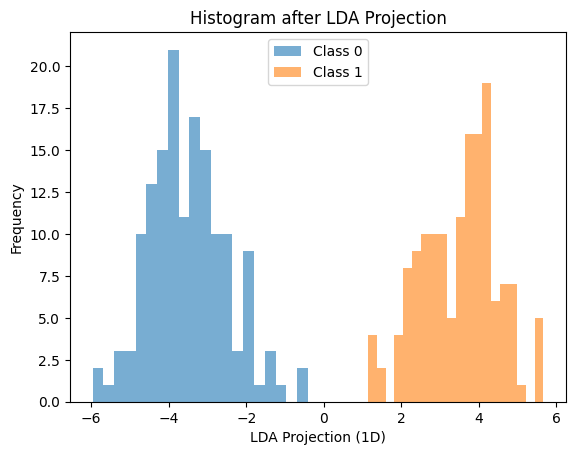

In [5]:
plt.figure()
for label in np.unique(y):
    plt.hist(X_lda[y == label], bins=20, alpha=0.6, label=f'Class {label}')

plt.xlabel('LDA Projection (1D)')
plt.ylabel('Frequency')
plt.title('Histogram after LDA Projection')
plt.legend()
plt.show()

## Class Means in Projected Space

In [6]:
for label in np.unique(y):
    print(f'Class {label} mean:', X_lda[y == label].mean())

Class 0 mean: -3.5022614153057368
Class 1 mean: 3.5022614153057385


[[ 5.14762345  1.35023781]
 [ 5.59776752 -0.51911041]
 [-2.52944346  7.42771973]
 [ 5.46052491  1.66988071]
 [ 5.07454112  5.08627088]
 [ 2.33870758  3.88968492]
 [-2.18805701  7.14567796]
 [ 5.1525128   4.78742594]
 [-2.01230248 10.47760382]
 [ 0.28946414  9.72503551]
 [-3.41015566  8.5767455 ]
 [-3.39324476 10.28868927]
 [-1.27538025  7.18302065]
 [-2.50152744  8.66240543]
 [ 6.92456495  2.78153475]
 [-2.3635813  10.46725361]
 [ 2.13577091  2.78820997]
 [ 0.70671851  9.96516466]
 [-3.30383793  9.78418728]
 [-0.40500616  6.91150953]
 [-3.97122013 10.19491303]
 [-3.0232694   7.81087022]
 [ 4.62150868  0.62728813]
 [ 4.4793333   0.4203062 ]
 [-3.2134092   9.82812619]
 [ 4.76976352  1.73965383]
 [ 7.86965252  0.82214834]
 [ 4.78537278  2.86590522]
 [ 3.50117984  2.19876036]
 [-2.8772798   7.88368188]
 [-1.62891198 12.29996957]
 [-1.5706966   7.72854979]
 [ 7.58696654  2.02606501]
 [-3.17897005 10.29888432]
 [ 4.78639298  0.81365501]
 [-1.2889218   7.16798965]
 [ 6.19618875  1.20814509]
 

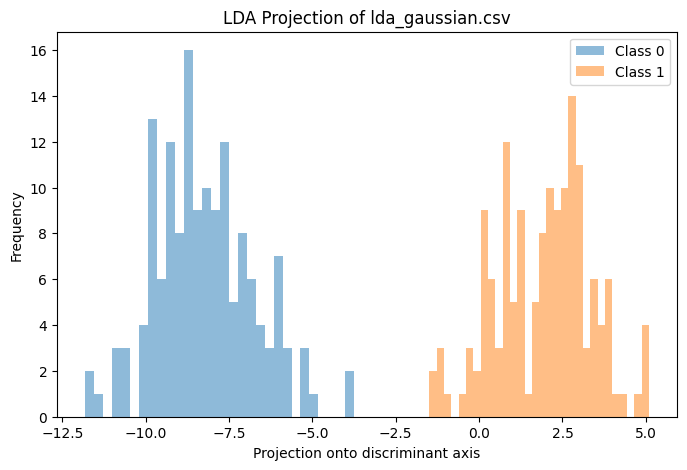

In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Step 1: Load your dataset
# Assuming lda_gaussian.csv has features in columns and a 'class' column for labels
data = pd.read_csv("lda_gaussian.csv")
X = df.iloc[:, :-1].values
y = df.iloc[:, -1].values
print(X)
print(y)

plt.figure(figsize=(8,5))
for cl in np.unique(y):
    plt.hist(X_lda[y == cl], bins=30, alpha=0.5, label=f"Class {cl}")
plt.xlabel("Projection onto LDA axis")
plt.ylabel("Frequency")
plt.legend()
plt.title("Class separation in LDA projection")
plt.show()

# Step 2: Use the function we defined earlier
def lda_discriminant_axis(X, y):
    classes = np.unique(y)
    mean_vectors = [np.mean(X[y == cl], axis=0) for cl in classes]
    overall_mean = np.mean(X, axis=0)

    # Within-class scatter
    S_W = np.zeros((X.shape[1], X.shape[1]))
    for cl, mv in zip(classes, mean_vectors):
        class_scatter = np.zeros((X.shape[1], X.shape[1]))
        for row in X[y == cl]:
            row, mv = row.reshape(-1, 1), mv.reshape(-1, 1)
            class_scatter += (row - mv).dot((row - mv).T)
        S_W += class_scatter

    # Between-class scatter
    S_B = np.zeros((X.shape[1], X.shape[1]))
    for cl, mv in zip(classes, mean_vectors):
        n = X[y == cl].shape[0]
        mv = mv.reshape(-1, 1)
        overall_mean = overall_mean.reshape(-1, 1)
        S_B += n * (mv - overall_mean).dot((mv - overall_mean).T)

    eig_vals, eig_vecs = np.linalg.eig(np.linalg.inv(S_W).dot(S_B))
    w = eig_vecs[:, np.argmax(eig_vals)]
    return w.real

# Step 3: Compute discriminant axis
axis = lda_discriminant_axis(X, y)
print("Discriminant axis:", axis)

# Step 4: Project data onto this axis
X_proj = X.dot(axis)

# Step 5: Plot the projection
plt.figure(figsize=(8,5))
for cl in np.unique(y):
    plt.hist(X_proj[y == cl], bins=30, alpha=0.5, label=f"Class {cl}")
plt.xlabel("Projection onto discriminant axis")
plt.ylabel("Frequency")
plt.legend()
plt.title("LDA Projection of lda_gaussian.csv")
plt.show()


In [ ]:


1. Do the two classes separate clearly after projection?
✅ Yes — if the dataset is well-suited for LDA, the projection onto the discriminant axis maximizes the separation between classes. You should see distinct clusters with minimal overlap in the projected space.

2. What property of the dataset helps LDA perform well?
Class separability: LDA works best when classes are linearly separable and the within-class variance is small compared to the between-class variance.

Gaussian-like distributions: If each class is approximately normally distributed with similar covariance structures, LDA performs especially well.

3. How are class means positioned in the projected space?
The class means are pushed far apart along the discriminant axis.

LDA explicitly maximizes the distance between class means while minimizing the spread within each class, so the projected means act like anchors for separation.

4. Would Principal Component Analysis (PCA) also perform well here? Why or why not?
Not necessarily. PCA is unsupervised — it only maximizes variance in the data, without considering class labels.

If the directions of maximum variance align with class separation, PCA may help. But if variance is dominated by noise or irrelevant features, PCA won’t separate classes effectively.

LDA, being supervised, is generally superior for classification tasks because it directly optimizes for class discrimination.

👉 In short: LDA separates classes clearly when distributions are well-behaved, class means are maximized apart in the projection, and PCA may not perform as well since it ignores labels.

Would you like me to illustrate this with a side-by-side visualization of LDA vs PCA projections so you can see the difference in class separation?




